In [21]:
# ============================================================
# Differential Imaging Attack (DIA) on CV-Deep2S (Full-Image Loss)
# ------------------------------------------------------------
# - Model: CV-Deep2S (complex-valued Deep2S, UNet3D with 2-channel input)
# - Physics: A^H y using experimental near-field MIMO operator A
# - Attack: complex aperture gains A_p, reparameterized via tanh
# - Loss: global 3D MSE(x_att, x_target) + λ ||A||_2^2 (no ROI)
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

from src import src  # assumes src.py is on your PYTHONPATH

# For reproducibility
np.random.seed(0)
tf.random.set_seed(0)

In [22]:
# ============================================================
# 1. Load observation model A and experimental measurements y
# ============================================================

# --- 1.1 Physics-based observation model A (K,T,R,X,Y,Z) ---
A_path = "models/experimental/A15_exp.npy"
A = np.load(A_path)  # complex-valued
print("A.shape =", A.shape)
K, T, R, X, Y, Z = A.shape

# --- 1.2 Clean experimental measurements y_clean (1,K,T,R) ---
y_path = "data/y_exp_test_4.npy"
y_exp = np.load(y_path)                         # (K,T,R)
y_clean = y_exp[None, ...].astype(np.complex64)  # (1,K,T,R)
print("y_clean.shape =", y_clean.shape)

# Flatten aperture dimension for attack construction
Np = T * R
X_v_flat = y_clean[0].reshape(K, Np)  # (K, Np)
print("Flattened victim measurements X_v_flat shape:", X_v_flat.shape)

# --- 1.3 Attack dictionary D_flat (K, Np), complex ---
D_flat_path = "data/D_flat.npy"
D_flat_np = np.load(D_flat_path)  # (K, Np)
assert D_flat_np.shape == X_v_flat.shape
print("D_flat.shape =", D_flat_np.shape)

A.shape = (15, 16, 9, 25, 25, 49)
y_clean.shape = (1, 15, 16, 9)
Flattened victim measurements X_v_flat shape: (15, 144)
D_flat.shape = (15, 144)


In [23]:
# ============================================================
# 2. TensorFlow constants and CV-Deep2S network
# ============================================================

# Observation model in TF
A_tf      = tf.constant(A.astype(np.complex64))        # (K,T,R,X,Y,Z)
A_conj_tf = tf.math.conj(A_tf)                         # (K,T,R,X,Y,Z)

# Victim measurements and attack dictionary in TF
X_v_flat_tf = tf.constant(X_v_flat.astype(np.complex64))     # (K,Np)
D_flat      = tf.constant(D_flat_np.astype(np.complex64))    # (K,Np)

# --- 2.1 Load pretrained CV-Deep2S UNet3D (2-channel input) ---
DNN = src.get_CV_UNet(input_shape=(X, Y, Z, 2))
DNN.load_weights("models/experimental/CV-Deep2S/model_Nf15_SNR30_CV_exp.h5")
print("Loaded CV-Deep2S UNet3D weights.")

Loaded CV-Deep2S UNet3D weights.


x_clean_mag.shape = (25, 25, 49)


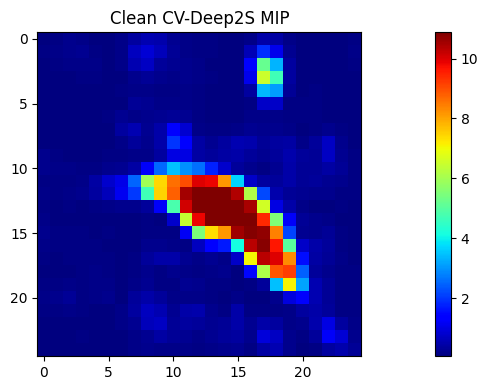

In [27]:
# ============================================================
# 3. CV-Deep2S forward operator implemented in TF
# ============================================================

def cv_deep2s_forward_tf(y_batch):
    """
    CV-Deep2S forward mapping in TensorFlow.

    Args
    ----
    y_batch : tf.Tensor, shape (N, K, T, R), complex64
        Batch of experimental measurements.

    Returns
    -------
    x_hat_mag : tf.Tensor, shape (N, X, Y, Z), float32
        RMS-normalized reconstructed magnitude volumes.
    """
    # 1) Adjoint physics: A^H y : (K,T,R,X,Y,Z) & (N,K,T,R) -> (N,X,Y,Z)
    AHy = tf.einsum('ktrxyz,Nktr->Nxyz', A_conj_tf, y_batch)  # complex64, (N,X,Y,Z)

    # 2) Per-sample max normalization (on magnitude, but applied to complex image)
    mag     = tf.abs(AHy)                                      # float32, (N,X,Y,Z)
    max_mag = tf.reduce_max(mag, axis=(1, 2, 3), keepdims=True)  # float32, (N,1,1,1)

    # Cast max_mag to complex so division is complex/complex
    max_mag_c = tf.cast(max_mag + 1e-12, tf.complex64)
    AHy_norm  = AHy / max_mag_c                                # complex64, (N,X,Y,Z)

    # 3) Form 2-channel (Re, Im) input to the CV-UNet
    AHy_ri = tf.stack(
        [tf.math.real(AHy_norm), tf.math.imag(AHy_norm)],
        axis=-1
    )  # (N,X,Y,Z,2), float32

    # 4) Pass through UNet prior
    x_hat = DNN(AHy_ri, training=False)   # (N,X,Y,Z,1) or (N,X,Y,Z)

    if tf.is_tensor(x_hat) and x_hat.dtype.is_complex:
        x_hat = tf.abs(x_hat)

    if len(x_hat.shape) == 5:
        x_hat = x_hat[..., 0]  # (N,X,Y,Z)

    # 5) RMS normalization to match MATLAB post-processing
    rms = tf.sqrt(tf.reduce_mean(x_hat**2, axis=(1, 2, 3), keepdims=True) + 1e-12)
    x_hat = x_hat / rms

    return x_hat  # (N,X,Y,Z), float32
    
x_clean_mag = cv_deep2s_forward_tf(tf.constant(y_clean)).numpy()[0]

print("x_clean_mag.shape =", x_clean_mag.shape)

# 2D MIP for quick visualization
clean_mip = x_clean_mag.max(axis=2)
plt.figure(figsize=(15,4))
plt.imshow(clean_mip, origin='upper', cmap='jet')
plt.title("Clean CV-Deep2S MIP")
plt.colorbar()
plt.tight_layout()
plt.show()

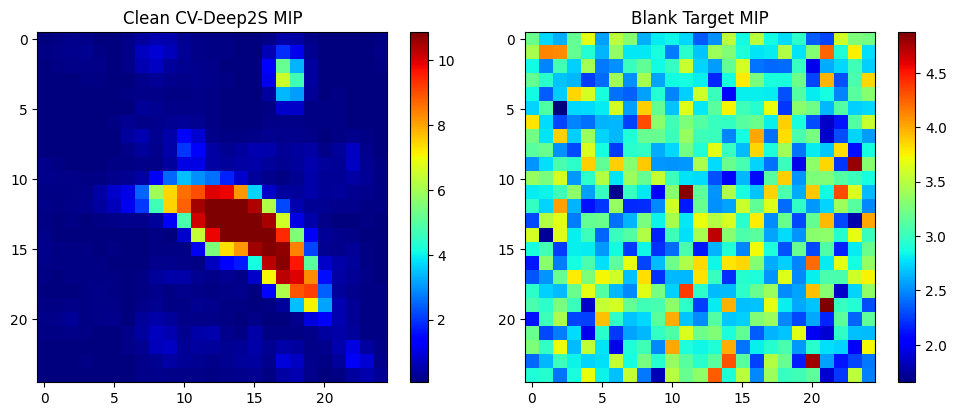

In [28]:
# ============================================================
# 4. Construct "blank" target volume (global camouflage target)
# ============================================================

# Use a dark corner pixel of the clean MIP as background reference
clean_mip   = x_clean_mag.max(axis=2)          # (X,Y)
bg_val      = float(clean_mip[0, 0])
drange      = float(clean_mip.max() - clean_mip.min())

# Base volume at bg_val
base = np.full((X, Y, Z), bg_val, dtype=np.float32)

# Add small Gaussian noise to avoid trivial constant target
np.random.seed(1234)
noise_std = 0.05 * drange
noise     = noise_std * np.random.randn(X, Y, Z).astype(np.float32)

x_target = base + noise
x_target = np.clip(x_target, 0.0, None)

# RMS normalization of target volume
rms_tgt  = np.sqrt(np.mean(x_target**2) + 1e-12)
x_target = x_target / rms_tgt

# TF wrapper
x_target_tf  = tf.constant(x_target[None, ...])   # (1,X,Y,Z)
x_target_mip = x_target.max(axis=2)               # (X,Y)

# Quick visualization of target vs clean
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(clean_mip, origin='upper', cmap='jet')
plt.title("Clean CV-Deep2S MIP")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(x_target_mip, origin='upper', cmap='jet')
plt.title("Blank Target MIP")
plt.colorbar()
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# 5. Full-image attack loss: global MSE + L2 regularization
# ============================================================

def attack_loss(A_re, A_im, lambda_L2=0.0):
    """
    Full-image differential imaging attack objective for CV-Deep2S.

    L = MSE( x_att, x_target )  +  lambda_L2 * ||A||_2^2

    where the MSE is computed over *all* voxels in the 3D volume
    (no ROI restriction).
    """
    # Complex gains A_p (Np apertures)
    A_complex = tf.complex(A_re, A_im)          # (Np,)
    A_col     = tf.reshape(A_complex, (1, Np))  # (1,Np)

    # Build attacked measurements Y = X_v_flat + D_flat .* A^T
    Y_flat  = X_v_flat_tf + D_flat * A_col      # (K,Np)
    Y_batch = tf.reshape(Y_flat, (1, K, T, R))  # (1,K,T,R)

    # CV-Deep2S reconstruction
    x_hat_mag = cv_deep2s_forward_tf(Y_batch)   # (1,X,Y,Z)
    x_hat = x_hat_mag[0]                        # (X,Y,Z)
    x_tgt = x_target_tf[0]                      # (X,Y,Z)

    # Global image-domain MSE
    diff   = x_hat - x_tgt
    mse_im = tf.reduce_mean(diff**2)

    # L2 regularization on A
    reg = lambda_L2 * tf.reduce_mean(tf.abs(A_complex)**2)

    return mse_im + reg, mse_im, reg, x_hat_mag


In [37]:
# ============================================================
# 6. DIA loop: reparameterized A and Adam optimization
# ============================================================

Amax      = 2.0        # physical amplitude bound on |A_p|
lambda_L2 = 1e-5       # L2 weight (tune 1e-4–1e-2 as needed)
max_iter  = 300        # number of attack iterations

# Latent variables Z; A is obtained via a smooth tanh mapping
Z_re = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))
Z_im = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))

def get_A_from_Z(Z_re, Z_im, Amax=2.0):
    """
    Smooth parameterization:

        A_re = (Amax / sqrt(2)) * tanh(Z_re)
        A_im = (Amax / sqrt(2)) * tanh(Z_im)

    so each component lies in [-Amax/sqrt(2), Amax/sqrt(2)],
    which guarantees |A_p| <= Amax without explicit clipping.
    """
    scale = Amax / np.sqrt(2.0)
    A_re = scale * tf.tanh(Z_re)
    A_im = scale * tf.tanh(Z_im)
    return A_re, A_im

# Adam optimizer with simple 2-stage learning-rate schedule
optimizer      = tf.keras.optimizers.Adam(learning_rate=1e-1)
lr_switch_iter = 100
low_lr         = 1e-2

loss_hist  = []
meanA_hist = []
maxA_hist  = []

print("\nStarting DIA optimization on CV-Deep2S (Np = {})...".format(Np))

for it in range(1, max_iter + 1):

    # Learning-rate schedule: high LR, then lower after lr_switch_iter
    if it == lr_switch_iter + 1:
        optimizer.learning_rate.assign(low_lr)
        print(f"\n[LR SCHEDULE] Switched Adam LR to {low_lr}\n")

    with tf.GradientTape() as tape:
        A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)
        loss_total, loss_im, reg, x_hat_mag = attack_loss(
            A_re_cur, A_im_cur, lambda_L2=lambda_L2
        )

    # Gradients with respect to the latent variables Z
    grads = tape.gradient(loss_total, [Z_re, Z_im])
    optimizer.apply_gradients(zip(grads, [Z_re, Z_im]))

    # Logging of current A statistics
    A_re_val, A_im_val = get_A_from_Z(Z_re, Z_im, Amax=Amax)
    A_complex = tf.complex(A_re_val, A_im_val)
    A_now     = A_complex.numpy()
    meanA     = np.mean(np.abs(A_now))
    maxA      = np.max(np.abs(A_now))

    loss_hist.append(loss_total.numpy().item())
    meanA_hist.append(meanA)
    maxA_hist.append(maxA)

    if (it == 1) or (it % 5 == 0) or (it == max_iter):
        print(
            f"Iter {it:3d}/{max_iter:3d} | "
            f"Loss={loss_total.numpy():.6e} | "
            f"loss_im={loss_im.numpy():.6e} | reg={reg.numpy():.6e} | "
            f"mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("Attack optimization finished.")


Starting DIA optimization on CV-Deep2S (Np = 144)...
Iter   1/300 | Loss=1.726382e+00 | loss_im=1.726382e+00 | reg=4.644497e-11 | mean|A|=1.949e-01, max|A|=2.022e-01
Iter   5/300 | Loss=1.679099e+00 | loss_im=1.679097e+00 | reg=2.401931e-06 | mean|A|=5.392e-01, max|A|=8.788e-01
Iter  10/300 | Loss=1.603953e+00 | loss_im=1.603946e+00 | reg=6.836380e-06 | mean|A|=8.122e-01, max|A|=1.435e+00
Iter  15/300 | Loss=1.549969e+00 | loss_im=1.549958e+00 | reg=1.066179e-05 | mean|A|=9.934e-01, max|A|=1.731e+00
Iter  20/300 | Loss=1.521392e+00 | loss_im=1.521379e+00 | reg=1.326209e-05 | mean|A|=1.096e+00, max|A|=1.860e+00
Iter  25/300 | Loss=1.480930e+00 | loss_im=1.480915e+00 | reg=1.523790e-05 | mean|A|=1.173e+00, max|A|=1.913e+00
Iter  30/300 | Loss=1.464521e+00 | loss_im=1.464504e+00 | reg=1.687828e-05 | mean|A|=1.238e+00, max|A|=1.939e+00
Iter  35/300 | Loss=1.430754e+00 | loss_im=1.430736e+00 | reg=1.790183e-05 | mean|A|=1.276e+00, max|A|=1.952e+00
Iter  40/300 | Loss=1.422069e+00 | loss_im

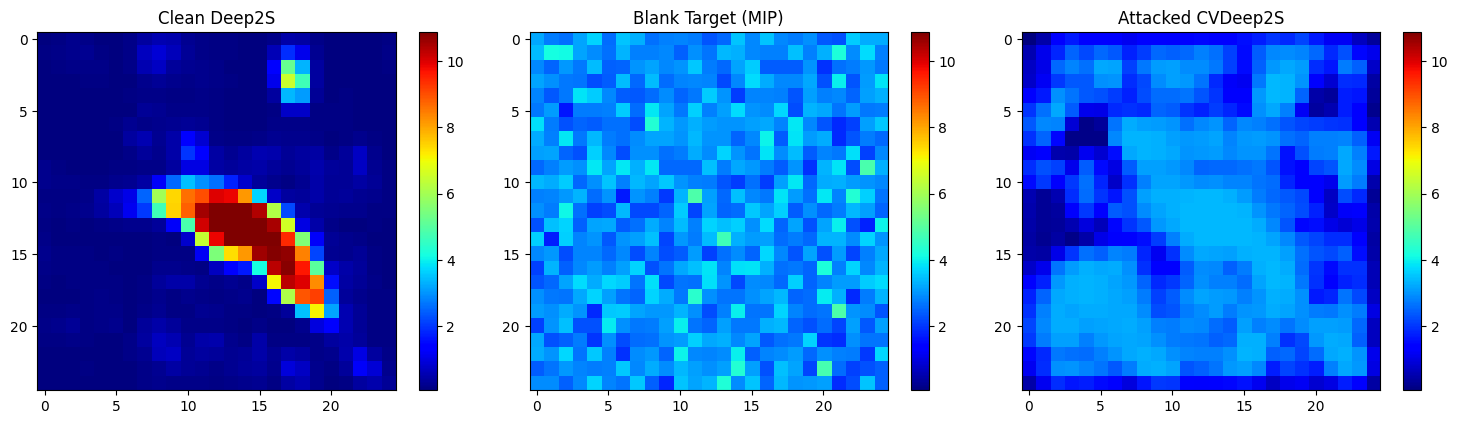

In [38]:
# ============================================================
# 8. Final attacked reconstruction and visualization
# ============================================================

# Compute final optimized A from Z
A_re_opt, A_im_opt = get_A_from_Z(Z_re, Z_im, Amax=Amax)
A_opt_tf  = tf.complex(A_re_opt, A_im_opt)       # (Np,)
A_opt_col = tf.reshape(A_opt_tf, (1, Np))        # (1,Np)

# Build attacked measurements and reconstruct
Y_opt_flat_tf = X_v_flat_tf + D_flat * A_opt_col       # (K,Np)
Y_opt_tf      = tf.reshape(Y_opt_flat_tf, (1, K, T, R))
x_att_mag     = cv_deep2s_forward_tf(Y_opt_tf).numpy()[0]  # (X,Y,Z)

# 2D MIPs over depth
clean_mip     = x_clean_mag.max(axis=2)
att_mip       = x_att_mag.max(axis=2)
target_mip  = x_target.max(axis=2)

vmin = clean_mip.min()
vmax = clean_mip.max()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(clean_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title('Clean Deep2S')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(x_target_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title('Blank Target (MIP)')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(att_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title('Attacked CVDeep2S')
plt.colorbar()

plt.tight_layout()
plt.show()


In [39]:
# ============================================================
# 9. Global MIP-level quantitative evaluation
# ============================================================

# Basic error metrics on 2D MIP
mse_mip  = np.mean((att_mip - target_mip) ** 2)
rmse_mip = np.sqrt(mse_mip)
mae_mip  = np.mean(np.abs(att_mip - target_mip))

# Normalized cross-correlation (NCC)
num = np.sum(att_mip * target_mip)
den = np.sqrt(np.sum(att_mip**2) * np.sum(target_mip**2)) + 1e-12
ncc_mip = num / den

# SSIM & PSNR on 2D MIP
data_range = float(target_mip.max() - target_mip.min() + 1e-12)
ssim_mip   = ssim(att_mip, target_mip, data_range=data_range)
psnr_mip   = psnr(target_mip, att_mip, data_range=data_range)

print("\n--- MIP-level attack metrics (full image) ---")
print(f"MSE   : {mse_mip:.4e}")
print(f"RMSE  : {rmse_mip:.4e}")
print(f"MAE   : {mae_mip:.4e}")
print(f"NCC   : {ncc_mip:.4f}")
print(f"SSIM  : {ssim_mip:.4f}")
print(f"PSNR  : {psnr_mip:.2f} dB")


--- MIP-level attack metrics (full image) ---
MSE   : 1.5919e+00
RMSE  : 1.2617e+00
MAE   : 9.5957e-01
NCC   : 0.9144
SSIM  : 0.0346
PSNR  : 8.13 dB
